# 01 - Exploratory Data Analysis

Fake job postings (EMSCAD / Kaggle `shivamb/real-or-fake-fake-jobposting-prediction`).
~17.8k postings, of which roughly 5% are fraudulent.

**Read this first.** A model that predicts "real" for every single posting scores about **95% accuracy** and catches **zero** scams. It is useless and it looks excellent. That is why this project is scored on **average precision (PR-AUC)**, which only rewards ranking the rare fraudulent class correctly.

The raw dataset has 17,880 postings. Removing 281 exact duplicates (identical on
every field but `job_id`) leaves 17,599, split 70/15/15 into train/val/test —
stratified on the target, so each split holds ~4.85% fraud.

EDA runs on the **training split only**. Val and test stay sealed until the models are scored, so nothing we learn here can leak into them.

Prerequisite: place `fake_job_postings.csv` in `data/raw/` (via `python -m src.data`, which needs Kaggle credentials), then run `python -m src.preprocessing` to build the splits.

In [7]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, evaluation, features, models, preprocessing

config.set_seed()
config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

In [8]:
train, _, _ = preprocessing.load_splits()
print(f"{len(train):,} training postings, {train.shape[1]} columns")
print(f"fraudulent: {train[config.TARGET].sum():,} ({train[config.TARGET].mean():.2%})")
train.head(3)

12,319 training postings, 51 columns
fraudulent: 600 (4.87%)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,question_count,has_email,has_url,has_phone,has_money,country,location_depth,salary_low,salary_high,salary_span
0,7269,Mobile Developer,"GR, ,",NaN,NaN,"OgilvyOne worldwide, Athens was established in...","OgilvyOne Worldwide, Athens seeks to recruit a...",Proficient programming skills in Java and/or O...,A competitive package matching the candidate's...,0,...,0,0,0,0,0,GR,1,-1.0,-1.0,-1.0
1,5878,.NET Architect,"US, PA, Philadelphia",NaN,NaN,Saras America's Microsoft Center of Excellence...,Title: .NET ArchitectStart Date: 11/18/2013End...,,,0,...,0,0,1,1,0,US,3,-1.0,-1.0,-1.0
2,1548,Account Manager,"GB, ,",Marketing,NaN,,We need an account manager to strenghten our M...,English is a must,,0,...,0,0,0,0,0,GB,1,-1.0,-1.0,-1.0


### Sanity checks

Two assumptions the rest of the project leans on, verified against the real data: the contact-detection features actually fire (they are not silently all-zero under EMSCAD's masking), and the trivial "always real" classifier scores ~95% while catching zero fraud — which is exactly why average precision, not accuracy, is the headline metric.

And the `has_money` feature carries real signal, not noise: fakes mention pay
figures nearly twice as often as real posts (41% vs 23%) — the "earnings bait"
pattern, captured as a feature rather than left in the text.

In [22]:
# Sanity checks against the real data.

# 1. Contact regexes must fire despite EMSCAD masking (#EMAIL_...#, #URL_...#, #PHONE_...#).
print("contact/money flag rates (share of postings):")
print(train[["has_email", "has_url", "has_phone", "has_money"]].mean().round(4))

# 2. "Always real" accuracy = 1 - fraud rate.
print(f"\nalways-real accuracy: {1 - train[config.TARGET].mean():.2%}")

# 3. has_money should separate the classes if the "earnings bait" intuition holds.
print("\nmoney-mention rate by class (real, fake):")
print(train.groupby(config.TARGET)["has_money"].mean().round(3))

contact/money flag rates (share of postings):
has_email    0.0731
has_url      0.3168
has_phone    0.1538
has_money    0.2346
dtype: float64

always-real accuracy: 95.13%

money-mention rate by class (real, fake):
fraudulent
0    0.226
1    0.408
Name: has_money, dtype: float64


## 1. The target is heavily imbalanced

The first plot is the whole reason for every methodological choice that follows.

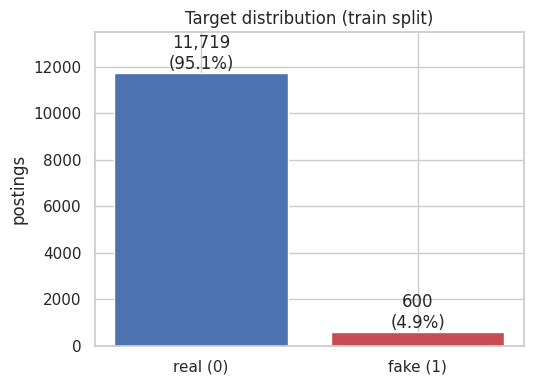

"always real" baseline accuracy: 95.13%
"always real" scams caught:      0 of 600
a random ranker scores AP = 0.0487 - that is the number to beat


In [10]:
counts = train[config.TARGET].value_counts().sort_index()
majority_share = counts.max() / counts.sum()

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(["real (0)", "fake (1)"], counts.values, color=["#4c72b0", "#c44e52"])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}\n({value / counts.sum():.1%})",
            ha="center", va="bottom")
ax.set_ylabel("postings")
ax.set_title("Target distribution (train split)")
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'"always real" baseline accuracy: {majority_share:.2%}')
print(f'"always real" scams caught:      0 of {counts.get(1, 0):,}')
print(f"a random ranker scores AP = {train[config.TARGET].mean():.4f} - that is the number to beat")

> **Insight 1.** Accuracy is unusable here: guessing "real" every time wins \~95% while catching nothing. Average precision for a random ranker equals the positive rate (0.05), so that is the real floor.

## 2. Missingness is the signal

Scammers do not fill in the boring fields. Compare how often each field is empty
for fake vs real postings - this is the single most useful thing in the dataset.

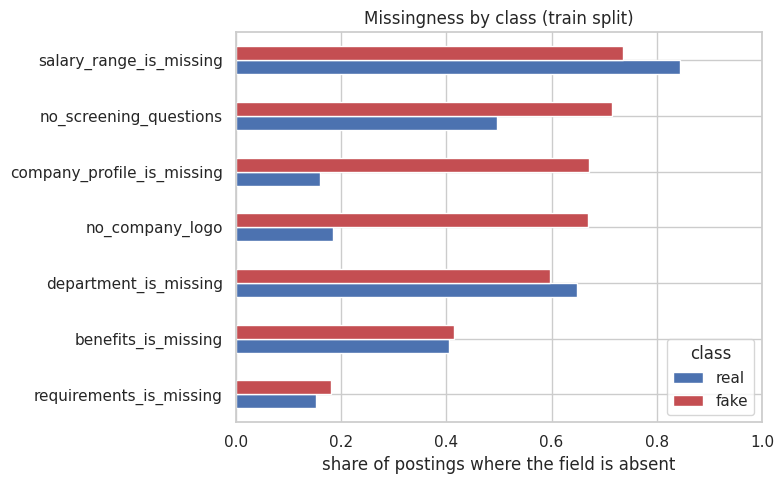

How much more often a field is missing for fakes (ratio):
company_profile_is_missing    4.23
no_company_logo               3.63
no_screening_questions        1.44
requirements_is_missing       1.19
benefits_is_missing           1.02
department_is_missing         0.92
salary_range_is_missing       0.87


In [11]:
flags = ["company_profile_is_missing", "salary_range_is_missing", "benefits_is_missing",
         "requirements_is_missing", "department_is_missing"]
rates = train.groupby(config.TARGET)[flags].mean().T
# has_company_logo / has_questions are presence flags, so invert them to read as "missing".
rates.loc["no_company_logo"] = 1 - train.groupby(config.TARGET)["has_company_logo"].mean()
rates.loc["no_screening_questions"] = 1 - train.groupby(config.TARGET)["has_questions"].mean()
rates.columns = ["real", "fake"]
rates = rates.sort_values("fake", ascending=True)

ax = rates.plot.barh(figsize=(8, 5), color=["#4c72b0", "#c44e52"])
ax.set_xlabel("share of postings where the field is absent")
ax.set_title("Missingness by class (train split)")
ax.set_xlim(0, 1)
ax.legend(title="class")
ax.figure.tight_layout()
ax.figure.savefig(config.FIGURES_DIR / "02_missingness_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

lift = (rates["fake"] / rates["real"].replace(0, np.nan)).sort_values(ascending=False)
print("How much more often a field is missing for fakes (ratio):")
print(lift.round(2).to_string())

> **Insight 2.** Fraudulent postings are far more likely to have no company profile, no company logo, and no screening questions — scammers skip the fields that take effort to set up, whether that is self-presentation or filtering applicants.
>
> This is why `src/features.py` builds an explicit `*_is_missing` flag for these instead of imputing them: the absence *is* the evidence.
>
> Missingness is not uniform, though. Salary range runs the other way — fakes omit it slightly *less* often (a quoted salary is bait, not proof), and requirements, benefits and department barely differ.
>
>The signal is the absence of the hard-to-fake, effortful fields, not of every field.

## 3. Text length separates the classes

Real postings are written by someone who wants the role filled. Scams are thinner.

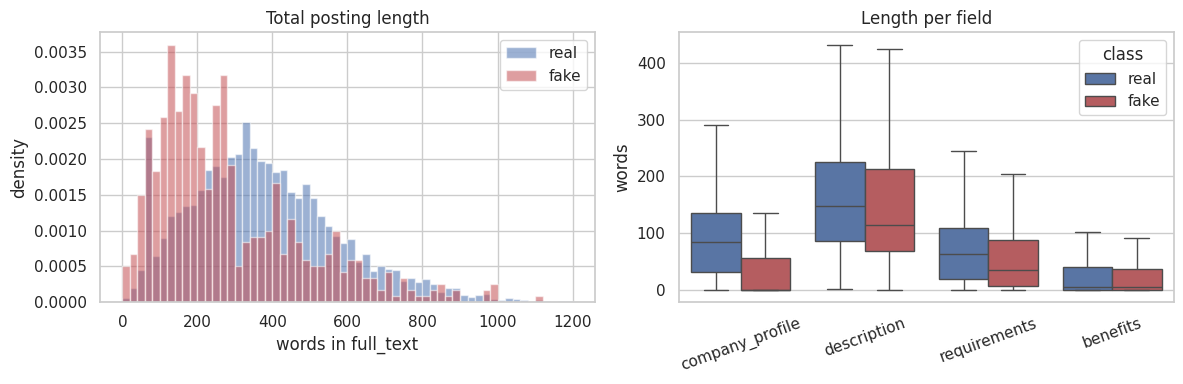

            full_text_word_count  caps_ratio  exclamation_count
fraudulent                                                     
0                          354.0       0.040                0.0
1                          232.5       0.047                0.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, name, colour in [(0, "real", "#4c72b0"), (1, "fake", "#c44e52")]:
    subset = train.loc[train[config.TARGET] == label, "full_text_word_count"]
    axes[0].hist(subset, bins=60, range=(0, 1200), alpha=0.55, density=True,
                 label=name, color=colour)
axes[0].set_xlabel("words in full_text")
axes[0].set_ylabel("density")
axes[0].set_title("Total posting length")
axes[0].legend()

length_cols = ["company_profile_word_count", "description_word_count",
               "requirements_word_count", "benefits_word_count"]
melted = train.melt(id_vars=config.TARGET, value_vars=length_cols,
                    var_name="field", value_name="words")
melted["field"] = melted["field"].str.replace("_word_count", "", regex=False)
melted["class"] = melted[config.TARGET].map({0: "real", 1: "fake"})
sns.boxplot(data=melted, x="field", y="words", hue="class", ax=axes[1], showfliers=False,
            palette={"real": "#4c72b0", "fake": "#c44e52"})
axes[1].set_title("Length per field")
axes[1].set_ylabel("words")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "03_text_length_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

print(train.groupby(config.TARGET)[["full_text_word_count", "caps_ratio",
                                    "exclamation_count"]].median().round(3).to_string())

In [19]:
# Is fake company_profile short only because it's usually missing, or ALSO when present?
present = train[train["company_profile"].str.len() > 0]
print("company_profile words WHEN PRESENT (median), by class:")
print(present.groupby(config.TARGET)["company_profile_word_count"].median())

# description is ~never missing, so its length gap is an independent signal.
print("\ndescription present rate (expect ~1.0 both classes):")
print(train.groupby(config.TARGET)["description"].apply(lambda s: (s.str.len() > 0).mean()).round(3))
print("\ndescription words (median), by class:")
print(train.groupby(config.TARGET)["description_word_count"].median())

company_profile words WHEN PRESENT (median), by class:
fraudulent
0    97.0
1    98.0
Name: company_profile_word_count, dtype: float64

description present rate (expect ~1.0 both classes):
fraudulent
0    1.000
1    0.998
Name: description, dtype: float64

description words (median), by class:
fraudulent
0    147.0
1    115.0
Name: description_word_count, dtype: float64


> **Insight 3.** Fakes are shorter overall — median \~233 words vs \~354.
>
> The `company_profile` gap in the boxplot is really Insight 2's missingness resurfacing as zeros: *when a profile is actually present*, fakes and reals are the same length (~98 vs ~97 words).
>
> But `description`, which is present in ~99.8% of postings, is still markedly shorter for fakes (median 115 vs 147) — even the text scammers *do* write is thinner.
>
> `caps_ratio` and `exclamation_count` barely differ, so "shouting" is a weaker signal than length.

## 4. What the two classes actually say

Top bigrams by class, then word clouds. `wordcloud` is optional - the cell degrades
to the bar chart if it is not installed.

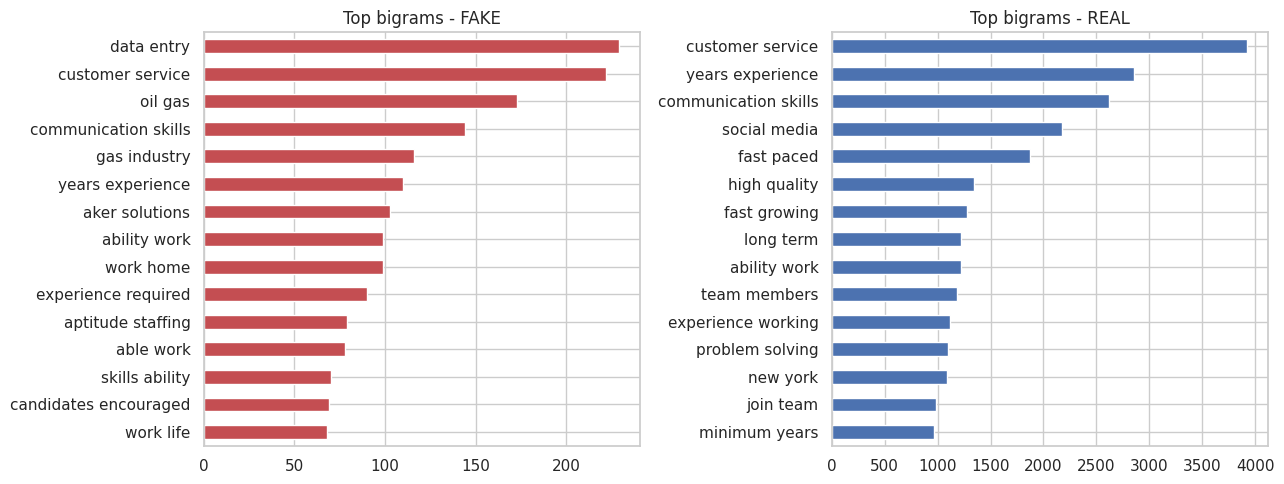

In [13]:
from sklearn.feature_extraction.text import CountVectorizer


def top_ngrams(texts, n=15, ngram_range=(2, 2)):
    """Most frequent n-grams in a set of documents."""
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=3)
    matrix = vec.fit_transform(texts)
    freqs = np.asarray(matrix.sum(axis=0)).ravel()
    order = np.argsort(-freqs)[:n]
    names = vec.get_feature_names_out()
    return pd.Series(freqs[order], index=names[order])


fake_text = train.loc[train[config.TARGET] == 1, config.FULL_TEXT_COLUMN]
real_text = train.loc[train[config.TARGET] == 0, config.FULL_TEXT_COLUMN]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_ngrams(fake_text).sort_values().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Top bigrams - FAKE")
top_ngrams(real_text).sort_values().plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top bigrams - REAL")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "04_top_ngrams.png", dpi=150, bbox_inches="tight")
plt.show()

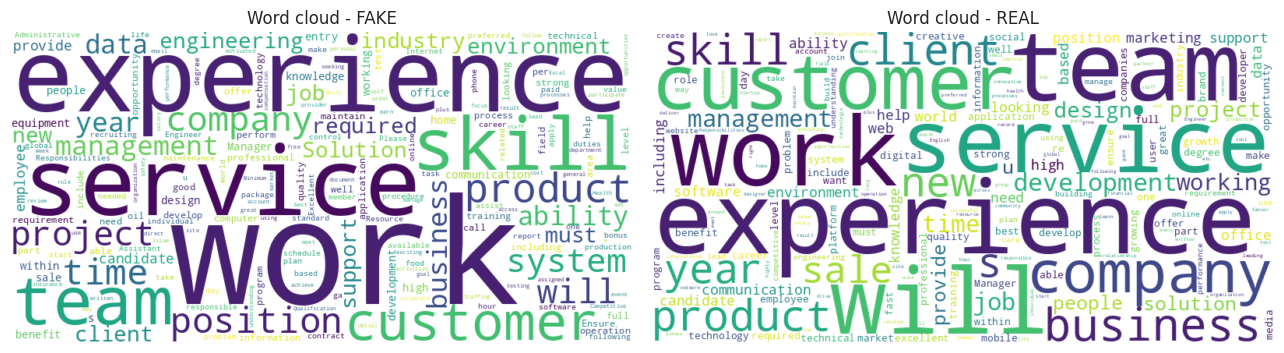

In [14]:
try:
    from wordcloud import WordCloud
except ImportError:
    print("wordcloud not installed - skipping (pip install wordcloud). Bigram chart above covers it.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, texts, title in [(axes[0], fake_text, "FAKE"), (axes[1], real_text, "REAL")]:
        cloud = WordCloud(width=800, height=400, background_color="white",
                          stopwords=None, random_state=config.SEED,
                          collocations=False).generate(" ".join(texts.head(2000)))
        ax.imshow(cloud, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Word cloud - {title}")
    fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / "05_wordclouds.png", dpi=150, bbox_inches="tight")
    plt.show()

> **Insight 4.** The word clouds barely separate the classes — both are dominated by generic *work / experience / service / team* — so the discriminating signal lives in **bigrams**, not single words (which is why the TF-IDF baseline uses ngram_range=(1,2)).
>
> There, fakes cluster around two things: entry-level remote work (`data entry`,
`work home`, `able work`) and a striking oil & gas campaign (`oil gas`, `gas industry`, `aker solutions`) — postings impersonating a real energy firm.
>
> Real ads read like ordinary corporate listings (`social media`, `fast paced`, `problem solving`, `team members`).
>
> Because the distinguishing terms are this concrete, a bag-of-words / TF-IDF model should already be a strong baseline — which is what notebook 02 tests.

## 5. Fraud rate by category

Absolute counts hide the story here; the fraud *rate* within each category is what
matters, so both are plotted together.

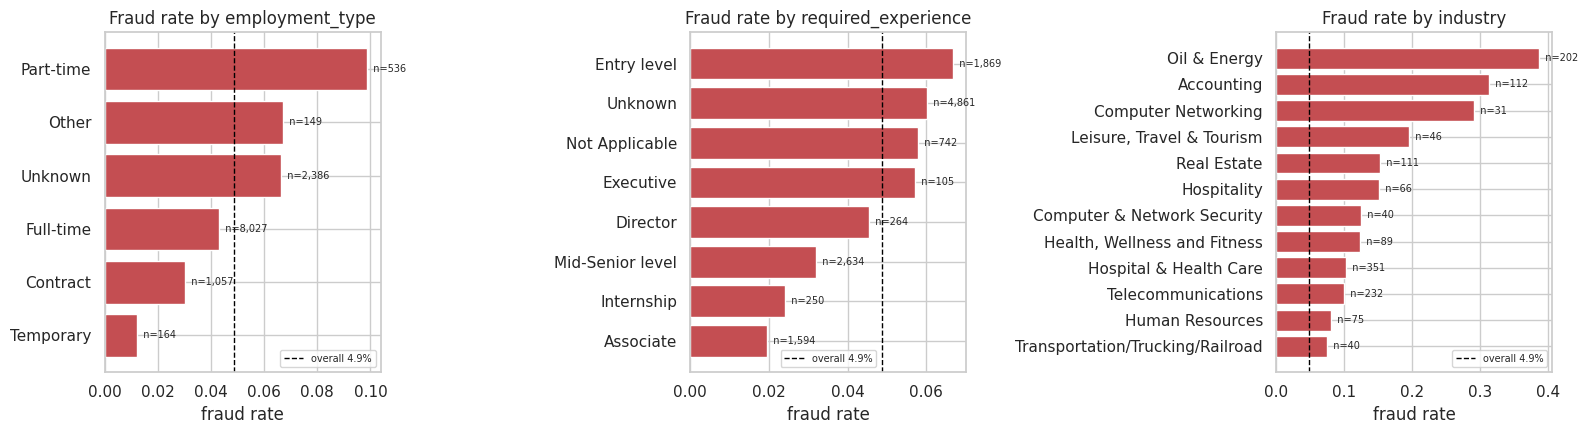

Highest-risk industries (min 30 postings):
                                   mean  count
industry                                      
Oil & Energy                      0.386    202
Accounting                        0.312    112
Computer Networking               0.290     31
Leisure, Travel & Tourism         0.196     46
Real Estate                       0.153    111
Hospitality                       0.152     66
Computer & Network Security       0.125     40
Health, Wellness and Fitness      0.124     89
Hospital & Health Care            0.103    351
Telecommunications                0.099    232
Human Resources                   0.080     75
Transportation/Trucking/Railroad  0.075     40


In [15]:
def fraud_rate_by(column, min_count=30, top=12):
    """Fraud rate per category, keeping only categories with enough support."""
    grouped = train.groupby(column)[config.TARGET].agg(["mean", "count"])
    grouped = grouped[grouped["count"] >= min_count]
    return grouped.sort_values("mean", ascending=False).head(top)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
overall = train[config.TARGET].mean()

for ax, column in zip(axes, ["employment_type", "required_experience", "industry"]):
    table = fraud_rate_by(column).sort_values("mean")
    ax.barh(table.index.astype(str), table["mean"], color="#c44e52")
    ax.axvline(overall, color="black", linestyle="--", linewidth=1,
               label=f"overall {overall:.1%}")
    for y, (rate, count) in enumerate(zip(table["mean"], table["count"])):
        ax.text(rate, y, f"  n={count:,}", va="center", fontsize=7)
    ax.set_title(f"Fraud rate by {column}")
    ax.set_xlabel("fraud rate")
    ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "06_fraud_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("Highest-risk industries (min 30 postings):")
print(fraud_rate_by("industry").assign(mean=lambda d: d["mean"].round(3)).to_string())

> **Insight 5.** Fraud is highly concentrated, not spread evenly.
>
> By industry the spread is enormous: `Oil & Energy` runs at \~39% fraud (n=202) — nearly 8x the 4.9% base rate — with `Accounting` (\~31%) and `Computer Networking` (\~29%) close behind.
>
> The oil & gas spike is the same campaign the bigrams flagged in Insight 4, now quantified.
>
> Employment type adds a milder signal (`part-time` \~2x the base), and by experience the risk sits at `entry level` and in postings where the field is simply `Unknown` — missing metadata is itself weak evidence.
>
> Because the signal clusters this sharply, the categorical fields earn their place alongside the text in the models.

## Takeaways

1. **~5% positives.** Accuracy is meaningless; the headline metric is average
   precision, with ROC-AUC and minority-class F1/precision/recall alongside.
2. **Missingness is the strongest cheap signal** - no company profile, no logo, no
   screening questions. Encoded explicitly as `*_is_missing` features rather than imputed away. (Salary is the exception - fakes omit it slightly *less*.)
3. **Length carries signal, tone barely does**: fakes are shorter overall, and their `description` stays shorter even though it is almost never missing. The
   `company_profile` gap, by contrast, is missingness resurfacing - not length. Caps and exclamation marks hardly differ.
4. **Vocabulary separates on bigrams, not single words** - the word clouds look alike, but bigrams expose fake clusters (`data entry`, `work home`) and a sharp oil & gas impersonation campaign. So a TF-IDF baseline with ngram_range=(1,2) should already be strong, and the transformer models have something real to learn.
5. **Risk concentrates hard by category**: `Oil & Energy` runs ~8x the base rate, with part-time and entry-level roles elevated too. The categorical fields earn their place next to the text.
6. **Money mentions are an "earnings bait" signal**: fakes name pay figures nearly twice as often (41% vs 23%), captured as the `has_money` feature.

A default 0.5 threshold is wrong for a problem this imbalanced. Every notebook from here on tunes the threshold on validation and only then reports on test.

Next: `02_baseline.ipynb`.